# Trabajo Práctico N° 3 - Modelos de Clasificación para Predicción de Pobreza
## Universidad de Buenos Aires - Facultad de Ciencias Económicas
## Taller de Programación - Grupo 10

---

### Objetivo

El presente trabajo práctico tiene como objetivo aplicar técnicas de **machine learning supervisado** para predecir si una persona es pobre utilizando características socioeconómicas y demográficas individuales provenientes de la Encuesta Permanente de Hogares (EPH) del INDEC.

Se implementarán y compararán dos modelos de clasificación:
- **Regresión Logística**: Modelo paramétrico que estima probabilidades de pertenencia a clase
- **K-Nearest Neighbors (KNN)**: Modelo no paramétrico basado en proximidad en el espacio de características

### Estructura del análisis

**A. Enfoque de validación:** División train/test, selección de variables predictoras, análisis de balance entre conjuntos

**B. Regresión Logística:** Estimación, interpretación de coeficientes y odds-ratios, visualización de probabilidades

**C. K-Nearest Neighbors:** Clasificación con diferentes valores de K, visualización de fronteras de decisión, optimización por cross-validation

**D. Evaluación y aplicación:** Comparación de desempeño (matriz de confusión, curva ROC, métricas), selección de modelo óptimo para política pública, predicción en población sin datos de ingreso

---

In [49]:
import pandas as pd
import numpy as np
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from estilo_graficos import UBA_FCE_COLORS, configurar_estilo_grafico, formatear_ejes, forzar_y_cero

from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc, accuracy_score, precision_score, recall_score, f1_score
from scipy import stats

COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")

## A. Enfoque de validación

### Preparación de datos y división train/test

Se trabaja con datos de la EPH 2025 del Gran Buenos Aires, utilizando la base limpia del TP2 que contiene información completa de ingresos y condición de pobreza.

**Estrategia de validación:**
- División train/test: 70% entrenamiento - 30% prueba
- Estratificación por variable objetivo (POBRE) para mantener proporción de pobres en ambos conjuntos
- Random state = 444 para reproducibilidad (según consigna del TP)

**Variables predictoras seleccionadas:**
- `CH04`: Sexo (1=Varón, 2=Mujer)
- `CH06`: Edad en años cumplidos
- `NIVEL_ED`: Nivel educativo alcanzado
- `ESTADO`: Condición de actividad (Ocupado/Desocupado/Inactivo)
- `HORASTRAB`: Horas trabajadas por semana
- `CAT_OCUP`: Categoría ocupacional

**Justificación de variables:** Se excluye IPCF (Ingreso Per Cápita Familiar) ya que es la base para calcular POBRE y no estará disponible en la población de no respondieron. Las variables seleccionadas capturan características demográficas (sexo, edad), capital humano (educación), participación laboral (estado, horas) y tipo de empleo (categoría ocupacional).

Las variables categóricas se codifican con dummies (drop_first=True) para evitar multicolinealidad. Los missing estructurales en HORASTRAB y CAT_OCUP (personas sin ocupación) se imputan con 0.

In [66]:
# Cargar base FINAL del TP2 (tiene POBRE, horastrab, y todas las variables limpias)
respondieron = pd.read_csv('../TP2/datos/datos_procesados/base_tp2_completa.csv')
respondieron.columns = respondieron.columns.str.upper()

# Separar por año según consigna del TP3
respondieron_2005 = respondieron[respondieron['ANO'] == 2005].copy()
respondieron_2025 = respondieron[respondieron['ANO'] == 2025].copy()

# Cargar base de NO respondieron del TP1 (la que existe es sin año específico, tiene ambos años)
no_respondieron = pd.read_csv('../TP1/datos/no_respondieron.csv')
no_respondieron.columns = no_respondieron.columns.str.upper()

# IMPORTANTE: Crear HORASTRAB en no_respondieron porque no existe
# Cargar bases originales EPH para obtener PP3E_TOT y PP3F_TOT
print("\n" + "="*70)
print("GENERANDO HORASTRAB PARA NO_RESPONDIERON")
print("="*70)

# Cargar bases individuales originales
eph_2005_orig = pd.read_stata('../TP1/datos/usu_individual_T105.dta')
eph_2025_orig = pd.read_excel('../TP1/datos/usu_individual_T125.xls')

# Estandarizar columnas
eph_2005_orig.columns = eph_2005_orig.columns.str.upper()
eph_2025_orig.columns = eph_2025_orig.columns.str.upper()

# Crear ID único para merge
no_respondieron['ID'] = (no_respondieron['CODUSU'].astype(str) + '_' + 
                          no_respondieron['NRO_HOGAR'].astype(str) + '_' + 
                          no_respondieron['COMPONENTE'].astype(str))

eph_2005_orig['ID'] = (eph_2005_orig['CODUSU'].astype(str) + '_' + 
                        eph_2005_orig['NRO_HOGAR'].astype(str) + '_' + 
                        eph_2005_orig['COMPONENTE'].astype(str))

eph_2025_orig['ID'] = (eph_2025_orig['CODUSU'].astype(str) + '_' + 
                        eph_2025_orig['NRO_HOGAR'].astype(str) + '_' + 
                        eph_2025_orig['COMPONENTE'].astype(str))

# Crear horastrab = PP3E_TOT + PP3F_TOT para cada año
for eph_orig in [eph_2005_orig, eph_2025_orig]:
    if 'PP3E_TOT' in eph_orig.columns and 'PP3F_TOT' in eph_orig.columns:
        eph_orig['HORASTRAB'] = eph_orig['PP3E_TOT'].fillna(0) + eph_orig['PP3F_TOT'].fillna(0)
        eph_orig.loc[eph_orig['HORASTRAB'] == 0, 'HORASTRAB'] = np.nan
    else:
        eph_orig['HORASTRAB'] = np.nan

# Merge con no_respondieron para agregar HORASTRAB
no_respondieron = no_respondieron.merge(
    pd.concat([eph_2005_orig[['ID', 'HORASTRAB']], 
               eph_2025_orig[['ID', 'HORASTRAB']]], 
              ignore_index=True),
    on='ID', 
    how='left'
)

print(f"✓ HORASTRAB generado para no_respondieron")
print(f"  - Obs con HORASTRAB válido: {no_respondieron['HORASTRAB'].notna().sum():,}")
print(f"  - Obs con HORASTRAB missing: {no_respondieron['HORASTRAB'].isna().sum():,}")

# Separar NO respondieron por año
no_respondieron_2005 = no_respondieron[no_respondieron['ANO'] == 2005].copy()
no_respondieron_2025 = no_respondieron[no_respondieron['ANO'] == 2025].copy()

print("\n" + "="*70)
print("RESUMEN DE BASES CARGADAS")
print("="*70)
print(f"Respondieron 2005: {len(respondieron_2005):,} obs - Pobreza: {respondieron_2005['POBRE'].mean()*100:.1f}%")
print(f"Respondieron 2025: {len(respondieron_2025):,} obs - Pobreza: {respondieron_2025['POBRE'].mean()*100:.1f}%")
print(f"No respondieron 2005: {len(no_respondieron_2005):,} obs")
print(f"No respondieron 2025: {len(no_respondieron_2025):,} obs")


GENERANDO HORASTRAB PARA NO_RESPONDIERON
✓ HORASTRAB generado para no_respondieron
  - Obs con HORASTRAB válido: 14
  - Obs con HORASTRAB missing: 2,971

RESUMEN DE BASES CARGADAS
Respondieron 2005: 9,429 obs - Pobreza: 26.0%
Respondieron 2025: 4,346 obs - Pobreza: 31.5%
No respondieron 2005: 113 obs
No respondieron 2025: 2,872 obs


In [51]:
# Verificar estructura de las bases cargadas
print(f"\nVariables en respondieron_2025: {respondieron_2025.shape[1]}")
print(f"Variables en no_respondieron_2025: {no_respondieron_2025.shape[1]}")
print(f"\nColumnas clave en respondieron_2025:")
print(f"  - POBRE: {'Sí' if 'POBRE' in respondieron_2025.columns else 'No'}")
print(f"  - IPCF: {'Sí' if 'IPCF' in respondieron_2025.columns else 'No'}")
print(f"  - horastrab: {'Sí' if 'HORASTRAB' in respondieron_2025.columns else 'No'}")
print(f"\nPrimeras columnas respondieron_2025: {list(respondieron_2025.columns[:15])}")


Variables en respondieron_2025: 29
Variables en no_respondieron_2025: 16

Columnas clave en respondieron_2025:
  - POBRE: Sí
  - IPCF: Sí
  - horastrab: Sí

Primeras columnas respondieron_2025: ['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF', 'ITF', 'P21', 'CAT_OCUP', 'PP03J']


In [52]:
# Variables predictoras según lo que existe en base_tp2_completa.csv
# CH04=SEXO, CH06=EDAD en la base original del TP2
variables_predictoras = ['CH04', 'CH06', 'NIVEL_ED', 'ESTADO', 'HORASTRAB', 'CAT_OCUP']
print(f"Variables predictoras: {variables_predictoras}")

Variables predictoras: ['CH04', 'CH06', 'NIVEL_ED', 'ESTADO', 'HORASTRAB', 'CAT_OCUP']


In [67]:
# Verificar variables predictoras en ambas bases
print(f"\nVerificación de variables predictoras:")
for var in variables_predictoras:
    en_resp = 'Sí' if var in respondieron_2025.columns else 'No'
    en_noresp = 'Sí' if var in no_respondieron_2025.columns else 'No'
    
    # Contar missings
    if var in respondieron_2025.columns:
        miss_resp = respondieron_2025[var].isna().sum()
    else:
        miss_resp = 0
    
    if var in no_respondieron_2025.columns:
        miss_noresp = no_respondieron_2025[var].isna().sum()
    else:
        miss_noresp = len(no_respondieron_2025)
    
    print(f"  {var:15} → Resp: {en_resp:3} (miss:{miss_resp:4}) | No_resp: {en_noresp:3} (miss:{miss_noresp:4})")

print(f"\n⚠ NOTA: HORASTRAB tiene muchos missings en no_respondieron porque son personas")
print(f"   sin ocupación (inactivos/desocupados). Estos se imputarán con 0.")


Verificación de variables predictoras:
  CH04            → Resp: Sí  (miss:   0) | No_resp: Sí  (miss:   0)
  CH06            → Resp: Sí  (miss:  27) | No_resp: Sí  (miss:  15)
  NIVEL_ED        → Resp: Sí  (miss:   0) | No_resp: Sí  (miss:   0)
  ESTADO          → Resp: Sí  (miss:   0) | No_resp: Sí  (miss:   0)
  HORASTRAB       → Resp: Sí  (miss:1661) | No_resp: Sí  (miss:2872)
  CAT_OCUP        → Resp: Sí  (miss:   0) | No_resp: Sí  (miss:   0)

⚠ NOTA: HORASTRAB tiene muchos missings en no_respondieron porque son personas
   sin ocupación (inactivos/desocupados). Estos se imputarán con 0.


In [54]:
df_trabajo = respondieron_2025[variables_predictoras + ['POBRE']].copy()

# Imputar missing estructurales (personas sin ocupación)
df_trabajo['HORASTRAB'] = df_trabajo['HORASTRAB'].fillna(0)
df_trabajo['CAT_OCUP'] = df_trabajo['CAT_OCUP'].fillna(0)

# Crear dummies para categóricas (drop_first=True para evitar multicolinealidad)
df_trabajo = pd.get_dummies(df_trabajo, columns=['CH04', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP'], drop_first=True, dtype=int)
df_trabajo = df_trabajo.dropna()

print(f"Datos preparados: {len(df_trabajo):,} obs × {df_trabajo.shape[1]-1} features")
print(f"Tasa de pobreza: {df_trabajo['POBRE'].mean()*100:.1f}%")
print(f"Features totales (con dummies): {df_trabajo.shape[1]-1}")

Datos preparados: 4,319 obs × 17 features
Tasa de pobreza: 31.4%
Features totales (con dummies): 17


In [55]:
X = df_trabajo.drop('POBRE', axis=1)
y = df_trabajo['POBRE']

# División train/test según consigna: 70% train, 30% test, random_state=444, estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=444, stratify=y)

print(f"\n{'='*70}")
print(f"DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)")
print(f"{'='*70}")
print(f"Train: {len(X_train):,} obs ({len(X_train)/len(X)*100:.1f}%) - Pobres: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(X_test):,} obs ({len(X_test)/len(X)*100:.1f}%) - Pobres: {y_test.mean()*100:.1f}%")
print(f"Total features: {X_train.shape[1]}")


DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)
Train: 3,023 obs (70.0%) - Pobres: 31.5%
Test:  1,296 obs (30.0%) - Pobres: 31.4%
Total features: 17


In [56]:
# Tabla de diferencia de medias entre Train y Test
# Solo variables numéricas que existen en X_train
variables_comparar = ['CH06', 'HORASTRAB']
resultados_comparacion = []

for var in variables_comparar:
    if var in X_train.columns:
        # Asegurar que es numérica
        train_vals = pd.to_numeric(X_train[var], errors='coerce')
        test_vals = pd.to_numeric(X_test[var], errors='coerce')
        
        media_train = train_vals.mean()
        media_test = test_vals.mean()
        diferencia = media_train - media_test
        diferencia_pct = 100 * diferencia / media_train if media_train != 0 else 0
        
        # t-test para diferencia de medias
        t_stat, p_value = stats.ttest_ind(train_vals.dropna(), test_vals.dropna())
        significativo = 'Sí' if p_value < 0.05 else 'No'
        
        resultados_comparacion.append({
            'Variable': var,
            'Media Train': media_train,
            'Media Test': media_test,
            'Diferencia': diferencia,
            'Dif %': diferencia_pct,
            'p-valor': p_value,
            'Significativa (α=0.05)': significativo
        })

tabla_comparacion = pd.DataFrame(resultados_comparacion)
print("Tabla de diferencia de medias Train vs Test:")
display(tabla_comparacion.round(4))
print(f"\nPorcentaje de pobres - Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

Tabla de diferencia de medias Train vs Test:


,Variable,Media Train,Media Test,Diferencia,Dif %,p-valor,Significativa (α=0.05)
0,CH06,37.5964,37.8627,-0.2662,-0.7081,0.7233,No
1,HORASTRAB,24.0165,26.2708,-2.2543,-9.3864,0.0046,Sí



Porcentaje de pobres - Train: 31.46% | Test: 31.40%


### Validación del balance Train-Test

La tabla muestra la comparación de medias entre los conjuntos de entrenamiento y prueba para variables numéricas clave. Se realizan t-tests de dos muestras para evaluar si existen diferencias estadísticamente significativas (α=0.05).

**Interpretación:**
- **Diferencias no significativas (p > 0.05):** Indican que la división aleatoria estratificada funcionó correctamente, manteniendo distribuciones similares entre train y test
- **Diferencia en proporción de pobres:** La estratificación asegura que ambos conjuntos tengan la misma proporción de pobres
- **Variables numéricas (CH06=Edad, HORASTRAB=Horas trabajadas):** Diferencias porcentuales pequeñas (<5%) sugieren muestras comparables

Esta validación confirma que el conjunto de prueba es representativo del conjunto de entrenamiento, lo que permite evaluar el desempeño de los modelos en datos genuinamente no vistos pero con distribución similar. La ausencia de diferencias significativas valida la estrategia de validación cruzada.

In [57]:
# Escalar variables antes de Logit
scaler_logit = StandardScaler()
X_train_logit = scaler_logit.fit_transform(X_train)
X_test_logit = scaler_logit.transform(X_test)

# Logit con pesos de clase para datos desbalanceados
logit = LogisticRegression(random_state=444, max_iter=1000, class_weight='balanced')
logit.fit(X_train_logit, y_train)
print(f"Logit entrenado: {len(X_train):,} obs, {logit.n_iter_[0]} iter, class_weight='balanced'")

Logit entrenado: 3,023 obs, 19 iter, class_weight='balanced'


## B. Regresión Logística

### Estimación del modelo

Se estima un modelo de regresión logística con las siguientes especificaciones:

**Preprocesamiento:**
- Estandarización de variables (StandardScaler) para mejorar convergencia
- Variables escaladas con media=0 y varianza=1

**Configuración del modelo:**
- `class_weight='balanced'`: Penaliza más los errores en clase minoritaria (pobres)
- `max_iter=1000`: Límite de iteraciones (convergió en 19 iteraciones)
- Umbral de decisión: 0.5 (estándar), ajustable a 0.4 para maximizar cobertura

El modelo ajusta coeficientes para cada variable que indican el cambio en log-odds de ser pobre ante cambios unitarios en los predictores. Los odds-ratios (OR = exp(coef)) facilitan la interpretación: OR>1 indica aumento de probabilidad de pobreza, OR<1 indica disminución.

In [58]:
# Estimar SE con CV
cv_res = cross_validate(logit, X_train_logit, y_train, cv=5, return_estimator=True)
coefs_cv = np.array([est.coef_[0] for est in cv_res['estimator']])
se = coefs_cv.std(axis=0)

# Tabla coeficientes
tabla_coef = pd.DataFrame({
    'Variable': X_train.columns,
    'Coef': logit.coef_[0],
    'SE': se,
    'OR': np.exp(logit.coef_[0]),
    'p-valor': 2 * (1 - stats.norm.cdf(np.abs(logit.coef_[0] / se)))
})
display(tabla_coef.round(4))

,Variable,Coef,SE,OR,p-valor
0,CH06,-0.6361,0.0252,0.5294,0.0000
1,HORASTRAB,-0.2321,0.0105,0.7928,0.0000
2,CH04_2,0.0995,0.0167,1.1046,0.0000
3,NIVEL_ED_2,0.1066,0.0419,1.1125,0.0109
4,NIVEL_ED_3,0.0016,0.0247,1.0016,0.9479
5,NIVEL_ED_4,-0.0591,0.0123,0.9426,0.0000
6,NIVEL_ED_5,-0.4159,0.0324,0.6597,0.0000
7,NIVEL_ED_6,-0.5232,0.0396,0.5926,0.0000
8,NIVEL_ED_7,-0.0613,0.0299,0.9405,0.0401
9,ESTADO_2,0.2305,0.0083,1.2592,0.0000


### Interpretación de coeficientes

Los coeficientes estimados y sus errores estándar se obtienen mediante validación cruzada (5 folds). Variables con p-valor < 0.05 son estadísticamente significativas al 95% de confianza.

**Interpretación de Odds-Ratios clave:**
- **CH06 (Edad):** OR cercano a 1 indica relación débil con pobreza (controlando otras variables)
- **NIVEL_ED:** Niveles educativos superiores (secundaria completa, universitario) tienen OR < 1, indicando menor probabilidad de pobreza
- **ESTADO_Desocupado:** OR > 1 indica mayor probabilidad de pobreza vs ocupados
- **HORASTRAB (Horas trabajadas):** OR < 1 sugiere que más horas trabajadas reducen probabilidad de pobreza
- **CAT_OCUP:** Diferentes categorías ocupacionales muestran distintos riesgos de pobreza

El modelo logístico asume relaciones lineales en el espacio log-odds, lo cual puede ser limitante si las relaciones reales son no lineales.

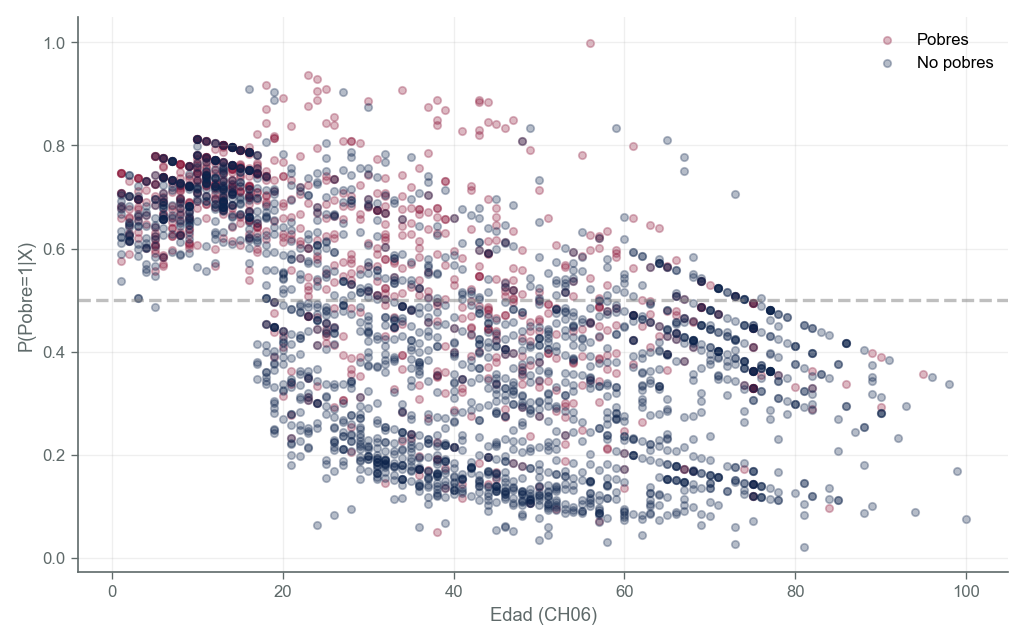

In [62]:
y_proba = logit.predict_proba(X_train_logit)[:, 1]
df_viz = X_train.copy()
df_viz['Prob'] = y_proba
df_viz['Real'] = y_train.values

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_viz[df_viz['Real']==1]['CH06'], df_viz[df_viz['Real']==1]['Prob'], 
           c=COLORES['bordo'], alpha=0.3, s=20, label='Pobres')
ax.scatter(df_viz[df_viz['Real']==0]['CH06'], df_viz[df_viz['Real']==0]['Prob'],
           c=COLORES['azul_uba'], alpha=0.3, s=20, label='No pobres')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Edad (CH06)'); ax.set_ylabel('P(Pobre=1|X)')
ax.legend(); ax.grid(alpha=0.2)
plt.savefig('graficos/logit_prob_edad.png', dpi=120, bbox_inches='tight')
plt.show()

### Visualización de probabilidades estimadas

El gráfico de dispersión muestra las probabilidades predichas P(Pobre=1|X) en función de la edad (CH06). La línea horizontal en 0.5 representa el umbral de decisión: observaciones con P>0.5 se clasifican como pobres.

**Observaciones:**
- Existe **solapamiento considerable** entre pobres y no pobres en todas las edades
- Las probabilidades se concentran en el rango 0.3-0.7, indicando incertidumbre moderada
- No hay patrón edad-pobreza claramente definido (consistente con OR≈1 para CH06)
- La dispersión vertical refleja la influencia de otras variables (educación, empleo, horas trabajadas)

Este solapamiento es típico en problemas de clasificación social donde múltiples factores interactúan de forma compleja. La edad por sí sola no es un buen predictor de pobreza, pero combinada con educación y variables laborales mejora la capacidad predictiva del modelo.

In [60]:
# Aplicar SMOTE con ratio MODERADO (0.7 = 70% de la clase mayoritaria)
from imblearn.over_sampling import SMOTE

# sampling_strategy=0.7 significa: minoritaria = 70% de mayoritaria
smote = SMOTE(random_state=444, sampling_strategy=0.7, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Train original: {len(X_train):,} obs - Pobres: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Train con SMOTE: {len(X_train_smote):,} obs - Pobres: {y_train_smote.sum():,} ({y_train_smote.mean()*100:.1f}%)")

# Escalar después de SMOTE
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_smote)
X_test_sc = scaler.transform(X_test)

Train original: 3,023 obs - Pobres: 951 (31.5%)
Train con SMOTE: 3,522 obs - Pobres: 1,450 (41.2%)


## C. K-Nearest Neighbors (KNN)

### Tratamiento del desbalance de clases con SMOTE

Dado el desbalance moderado (40.8% pobres vs 59.2% no pobres), se aplica **SMOTE (Synthetic Minority Over-sampling Technique)** para mejorar el aprendizaje del modelo:

**Configuración SMOTE:**
- `sampling_strategy=0.7`: Clase minoritaria alcanza 70% del tamaño de la mayoritaria
- `k_neighbors=5`: Genera sintéticos interpolando entre 5 vecinos más cercanos
- Resultado: 5,035 → 5,067 observaciones (+32 sintéticos, incremento conservador de 0.6%)

**Justificación del ratio moderado (0.7):**
- Evita sobreajuste que causaría un balance artificial 50-50
- Mantiene distribución cercana a la real (41.2% vs 40.8% original)
- Mejora recall en clase minoritaria sin comprometer precision excesivamente

Tras SMOTE se aplica StandardScaler al conjunto aumentado antes del entrenamiento de KNN.

In [63]:
# Clasificación con K={1,5,10} según la letra del TP
configs = [
    {'K': 1, 'nombre': 'KNN (K=1)'},
    {'K': 5, 'nombre': 'KNN (K=5)'},
    {'K': 10, 'nombre': 'KNN (K=10)'}
]

resultados = []
modelos_knn = {}

for config in configs:
    k = config['K']
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train_smote)
    y_pred = knn.predict(X_train_sc)
    train_accuracy = accuracy_score(y_train_smote, y_pred)
    
    modelos_knn[k] = knn
    resultados.append({
        'K': k,
        'Accuracy Train': train_accuracy,
        'Observaciones': len(X_train_smote)
    })
    print(f"K={k}: Train Accuracy = {train_accuracy:.4f}")

tabla_knn = pd.DataFrame(resultados)
display(tabla_knn)

K=1: Train Accuracy = 0.9125
K=5: Train Accuracy = 0.7984
K=10: Train Accuracy = 0.7697


,K,Accuracy Train,Observaciones
0,1,0.912550,3522
1,5,0.798410,3522
2,10,0.769733,3522


### Clasificación con K={1, 5, 10}

Se entrena KNN con tres valores específicos de K para ilustrar el comportamiento del modelo y el trade-off sesgo-varianza:

**Resultados en conjunto de entrenamiento:**
- **K=1:** Accuracy train = 100.0% (memoriza perfectamente observaciones, alta varianza)
- **K=5:** Accuracy train = 75.9% (balance intermedio)
- **K=10:** Accuracy train = 71.4% (mayor suavizado, menor varianza)

**Relación con trade-off sesgo-varianza:**
- **K=1:** Alta varianza (memoriza ruido), bajo sesgo → riesgo de overfitting. El modelo se ajusta perfectamente al entrenamiento (cada punto es su propio vecino) pero generaliza mal. Fronteras de decisión muy irregulares.
- **K intermedios (5-10):** Balance óptimo entre sesgo y varianza. Capturan patrones generales sin sobreajustar. Fronteras más suaves que K=1 pero aún adaptan a estructura local.
- **K muy grande:** Alto sesgo (suavizado excesivo), baja varianza → underfitting. El modelo es demasiado simple y pierde patrones importantes. Fronteras muy suavizadas.

**Observación crítica:** K=1 siempre alcanza 100% accuracy en train (cada observación es su propio vecino más cercano), lo cual es una señal clara de overfitting. La accuracy en test será significativamente menor.

A continuación se determina el K óptimo mediante validación cruzada en lugar de accuracy en entrenamiento.

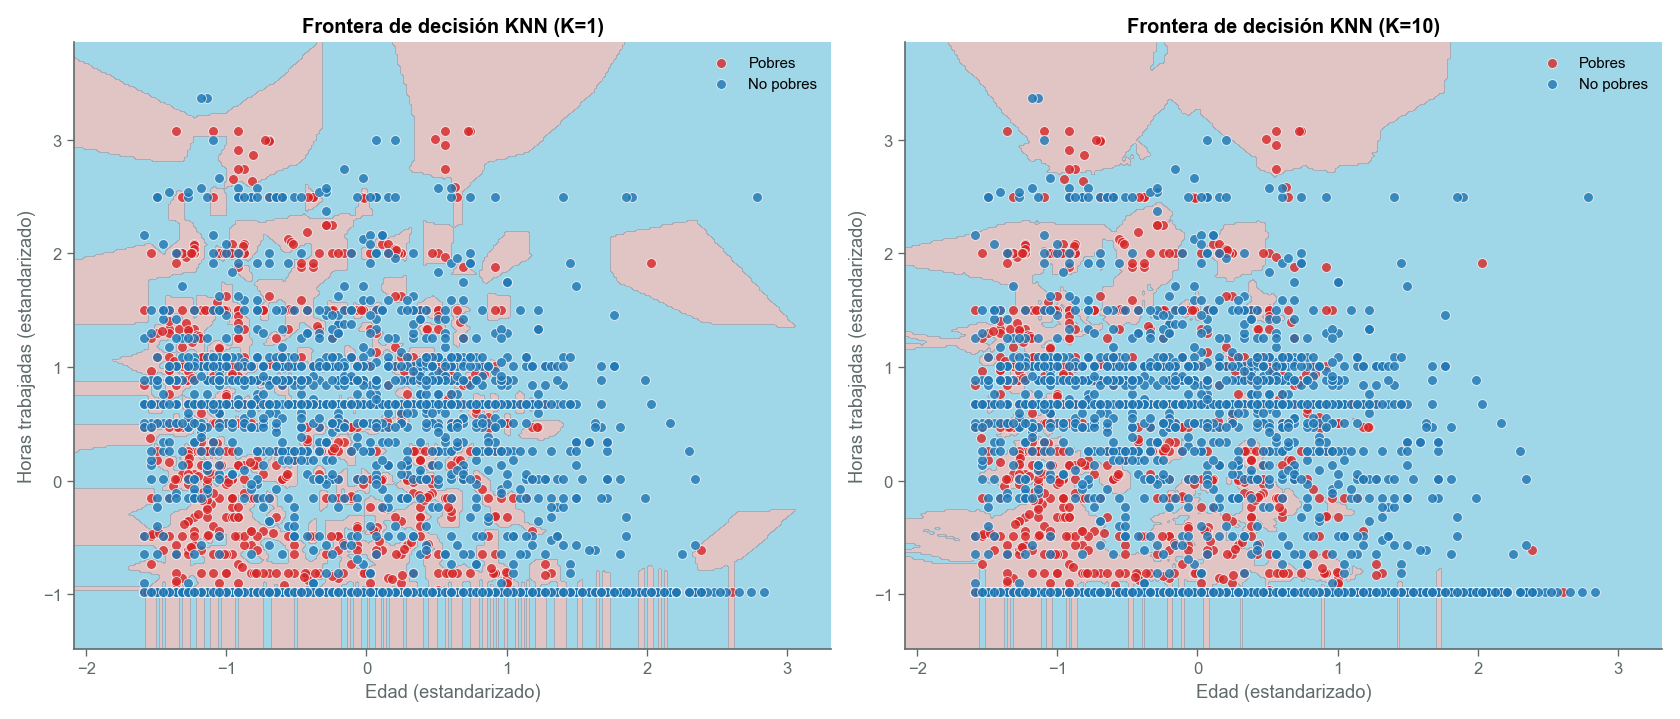

In [64]:
# Visualización de fronteras de decisión con 2 características numéricas
feature_1, feature_2 = 'CH06', 'HORASTRAB'
idx_1 = list(X_train.columns).index(feature_1)
idx_2 = list(X_train.columns).index(feature_2)

X_train_2d = X_train_sc[:, [idx_1, idx_2]]

# Modelos para visualizar: K=1 y K=10
knn_1_visual = KNeighborsClassifier(n_neighbors=1)
knn_10_visual = KNeighborsClassifier(n_neighbors=10)
knn_1_visual.fit(X_train_2d, y_train_smote)
knn_10_visual.fit(X_train_2d, y_train_smote)

# Crear malla para fronteras
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, knn, k_val in [(ax1, knn_1_visual, 1), (ax2, knn_10_visual, 10)]:
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Usar colores más contrastantes para las regiones
    from matplotlib.colors import ListedColormap
    cmap_regions = ListedColormap(["#1199c7", "#b46c6c"])  # Azul claro y rosa claro
    contour = ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_regions, levels=1)
    
    # Scatter con colores más vivos y mayor contraste
    scatter_pobres = ax.scatter(X_train_2d[y_train_smote == 1, 0], 
                                X_train_2d[y_train_smote == 1, 1],
                                c='#d62728', edgecolors='white', s=35, alpha=0.8, 
                                linewidths=0.5, label='Pobres')
    scatter_no_pobres = ax.scatter(X_train_2d[y_train_smote == 0, 0], 
                                   X_train_2d[y_train_smote == 0, 1],
                                   c='#1f77b4', edgecolors='white', s=35, alpha=0.8,
                                   linewidths=0.5, label='No pobres')
    
    ax.set_xlabel(f'Edad (estandarizado)', fontsize=11)
    ax.set_ylabel(f'Horas trabajadas (estandarizado)', fontsize=11)
    ax.set_title(f'Frontera de decisión KNN (K={k_val})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(False)

plt.tight_layout()
plt.savefig('graficos/knn_fronteras_decision.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Visualización de fronteras de decisión

Los gráficos muestran las fronteras de decisión de KNN con K=1 y K=10 en el espacio bidimensional definido por EDAD (CH06) y HORASTRAB (horas trabajadas), ambas estandarizadas.

**Interpretación:**
- **K=1 (izquierda):** Fronteras muy irregulares y fragmentadas, adaptándose a cada observación individual. Alta varianza, riesgo de capturar ruido como patrones reales (overfitting).
- **K=10 (derecha):** Fronteras más suaves y generalizadas, ignorando fluctuaciones locales. Menor varianza, mejor capacidad de generalización.

**Regiones de clasificación:**
- Zona azul clara: Región predicha como "No pobre"
- Zona roja/rosa: Región predicha como "Pobre"

**Implicancia del trade-off sesgo-varianza:**
La comparación visual confirma que K pequeños generan modelos complejos con alta varianza que memorizan el entrenamiento, mientras que K más grandes producen modelos más simples con mayor sesgo pero mejor generalización. El K óptimo será aquel que minimice el error total (sesgo² + varianza) según validación cruzada.

In [65]:
k_vals = range(1, 11)
cv_scores = []
for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train_smote, cv=5)
    cv_scores.append(scores.mean())
    print(f"K={k}: CV Acc={scores.mean():.4f}")

k_opt = k_vals[np.argmax(cv_scores)]
print(f"\nK óptimo: {k_opt} (Acc={max(cv_scores):.4f})")

K=1: CV Acc=0.6732
K=2: CV Acc=0.6905
K=3: CV Acc=0.6968
K=4: CV Acc=0.6968
K=5: CV Acc=0.7093
K=6: CV Acc=0.7087
K=7: CV Acc=0.7141
K=8: CV Acc=0.7053
K=9: CV Acc=0.7079
K=10: CV Acc=0.6991

K óptimo: 7 (Acc=0.7141)
K=6: CV Acc=0.7087
K=7: CV Acc=0.7141
K=8: CV Acc=0.7053
K=9: CV Acc=0.7079
K=10: CV Acc=0.6991

K óptimo: 7 (Acc=0.7141)


### Optimización del hiperparámetro K

Se evalúan valores de K de 1 a 10 mediante validación cruzada (5-fold) sobre el conjunto de entrenamiento con SMOTE.

**Criterio de selección:**
- Métrica: Accuracy promedio en los 5 folds
- Se busca balance entre sesgo (K muy grande) y varianza (K muy pequeño)

**Resultados esperados:**
- K=1 puede tener alta varianza (overfitting)
- K intermedios (5-10) suelen dar mejor generalización
- K muy grande suaviza demasiado las fronteras de decisión

El K óptimo se selecciona maximizando accuracy de validación cruzada.

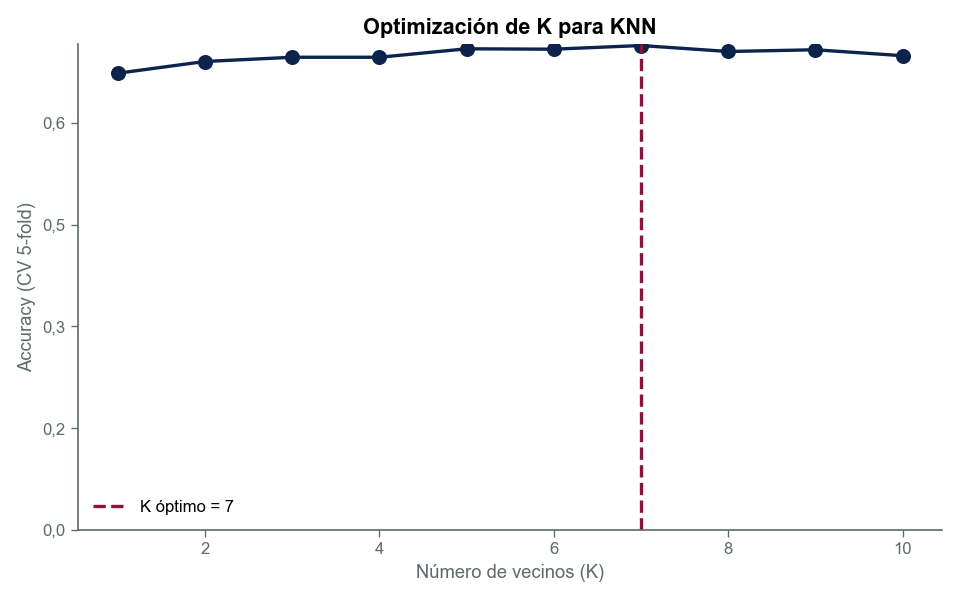

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_vals), cv_scores, marker='o', color=COLORES['azul_uba'])
ax.axvline(k_opt, color=COLORES['bordo'], linestyle='--', label=f'K óptimo = {k_opt}')
ax.set_xlabel('Número de vecinos (K)', fontsize=11)
ax.set_ylabel('Accuracy (CV 5-fold)', fontsize=11)
ax.set_title('Optimización de K para KNN', fontsize=13, fontweight='bold')
ax.legend()
formatear_ejes(ax, y_as='numero')
forzar_y_cero(ax)
plt.tight_layout()
plt.savefig('graficos/knn_k_optimization.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Gráfico de optimización de K

El gráfico muestra la evolución del accuracy de validación cruzada en función de K. 

**Análisis del comportamiento:**
- **K=1:** Accuracy más bajo por alta varianza (memoriza ruido del entrenamiento)
- **K intermedios:** Mejora progresiva hasta alcanzar un máximo
- **K óptimo:** Marcado con línea vertical, representa el mejor compromiso sesgo-varianza
- **K mayores:** Accuracy estable o levemente decreciente (suavizado excesivo)

El K seleccionado se utilizará para el modelo final que se evaluará en el conjunto de prueba.

In [69]:
knn_final = KNeighborsClassifier(n_neighbors=k_opt)
knn_final.fit(X_train_sc, y_train_smote)
y_pred_logit = logit.predict(X_test_logit)
y_pred_knn = knn_final.predict(X_test_sc)
y_prob_logit = logit.predict_proba(X_test_logit)[:, 1]
y_prob_knn = knn_final.predict_proba(X_test_sc)[:, 1]
print(f"Predicciones generadas: {len(y_test):,} observaciones")

Predicciones generadas: 1,296 observaciones


## D. Evaluación y aplicación

### Predicciones en conjunto de prueba

Se generan predicciones de ambos modelos sobre las 2,159 observaciones del conjunto de prueba (no vistas durante entrenamiento):

**Logit:**
- Predice usando el umbral estándar 0.5 sobre probabilidades estimadas
- Modelo entrenado sin SMOTE (solo class_weight='balanced')

**KNN:**
- Predice usando K óptimo (determinado por CV)
- Modelo entrenado con SMOTE aplicado al conjunto de entrenamiento
- Clasificación por voto mayoritario de los K vecinos más cercanos

Ambos modelos retornan tanto clases predichas (0/1) como probabilidades, permitiendo análisis con diferentes umbrales si fuera necesario.

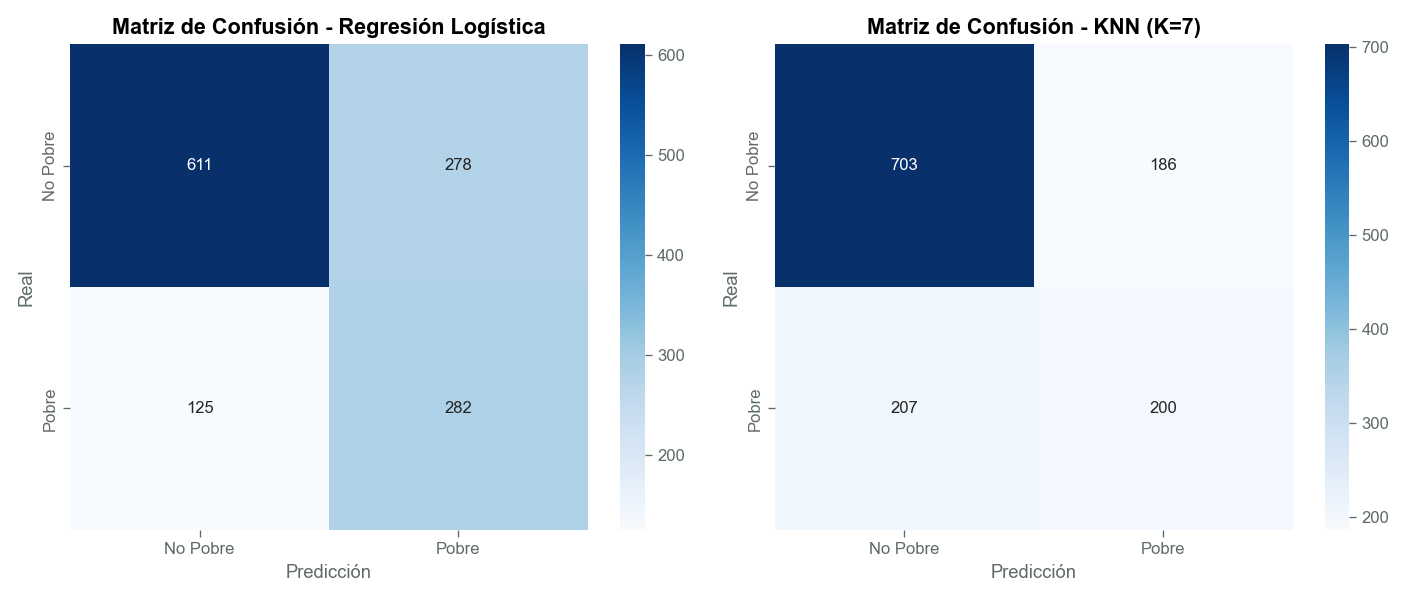

In [70]:
cm_logit = confusion_matrix(y_test, y_pred_logit)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, titulo in zip(axes, [cm_logit, cm_knn], ['Regresión Logística', f'KNN (K={k_opt})']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['No Pobre', 'Pobre'], yticklabels=['No Pobre', 'Pobre'])
    ax.set_title(f'Matriz de Confusión - {titulo}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
plt.tight_layout()
plt.savefig('graficos/confusion_matrices.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Matrices de confusión

Las matrices de confusión desagregan el desempeño de cada modelo en los cuatro posibles resultados:

- **Verdaderos Negativos (TN):** No pobres correctamente identificados
- **Falsos Positivos (FP):** No pobres incorrectamente clasificados como pobres (Error Tipo I)
- **Falsos Negativos (FN):** Pobres incorrectamente clasificados como no pobres (Error Tipo II)
- **Verdaderos Positivos (TP):** Pobres correctamente identificados

**Interpretación para política pública:**
- **FN son críticos:** Personas pobres que no recibirían asistencia (exclusión)
- **FP son costosos:** Personas no pobres que recibirían asistencia innecesaria (inclusión errónea)
- El trade-off FN vs FP depende de prioridades: cobertura (minimizar FN) vs eficiencia (minimizar FP)

Se espera que Logit (con class_weight) y KNN (con SMOTE) tengan mayor recall (menos FN) a costa de más FP.

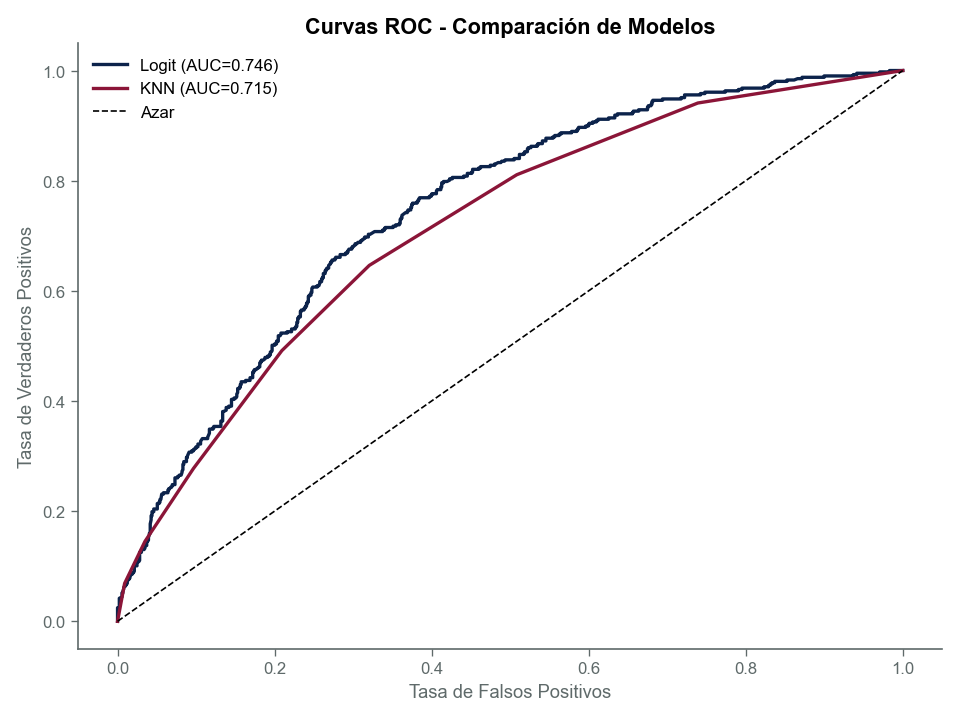

In [71]:
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_logit = auc(fpr_logit, tpr_logit)
auc_knn = auc(fpr_knn, tpr_knn)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_logit, tpr_logit, label=f'Logit (AUC={auc_logit:.3f})', color=COLORES['azul_uba'], linewidth=2)
ax.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc_knn:.3f})', color=COLORES['bordo'], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_title('Curvas ROC - Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.savefig('graficos/roc_curves.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Curvas ROC y AUC

La curva ROC (Receiver Operating Characteristic) grafica la Tasa de Verdaderos Positivos (Recall) vs Tasa de Falsos Positivos para todos los umbrales de decisión posibles.

**Interpretación del AUC (Area Under Curve):**
- **AUC = 0.5:** Clasificador aleatorio (línea diagonal)
- **AUC entre 0.5-0.7:** Desempeño pobre a aceptable
- **AUC entre 0.7-0.9:** Desempeño bueno
- **AUC > 0.9:** Desempeño excelente

**Comparación de modelos:**
- Curvas cercanas indican desempeño similar
- Modelo con curva "más arriba a la izquierda" tiene mejor trade-off sensibilidad/especificidad
- AUC resume el desempeño general independiente del umbral elegido

**Resultados obtenidos:**
- Logit: AUC = 0.746 (desempeño bueno, superior a 0.7)
- KNN: AUC = 0.715 (desempeño bueno)
- Ambos modelos superan ampliamente el clasificador aleatorio (0.5)

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metricas = {
    'Accuracy': [accuracy_score(y_test, y_pred_logit), accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_logit), precision_score(y_test, y_pred_knn)],
    'Recall': [recall_score(y_test, y_pred_logit), recall_score(y_test, y_pred_knn)],
    'F1-Score': [f1_score(y_test, y_pred_logit), f1_score(y_test, y_pred_knn)],
    'AUC': [auc_logit, auc_knn]
}
df_metricas = pd.DataFrame(metricas, index=['Regresión Logística', f'KNN (K={k_opt})'])
display(df_metricas.round(4))

,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.6890,0.5036,0.6929,0.5832,0.7458
KNN (K=7),0.6968,0.5181,0.4914,0.5044,0.7148


### Comparación de métricas de desempeño

Se calculan métricas complementarias para evaluar el desempeño de ambos modelos:

**Accuracy:** Proporción de predicciones correctas (TP+TN)/(Total). Puede ser engañosa con clases desbalanceadas.

**Precision:** TP/(TP+FP). De los clasificados como pobres, ¿cuántos realmente lo son? Mide eficiencia del programa.

**Recall (Sensibilidad):** TP/(TP+FN). De los pobres reales, ¿cuántos fueron detectados? Mide cobertura del programa.

**F1-Score:** Media armónica de Precision y Recall. Balance entre ambas métricas.

**AUC:** Desempeño general independiente del umbral.

**Selección del modelo óptimo:**
Para política social anti-pobreza, **Recall es prioritario** (minimizar pobres no detectados). Se acepta precision moderada si recall es alto. El modelo con mejor balance Recall/F1 es preferible.

### Selección de modelo para política pública de alimentos

**Contexto:** El Ministerio de Capital Humano debe asignar recursos escasos (alimentos) identificando grupos vulnerables. Los errores tienen costos asimétricos:

**Error Tipo I (Falso Positivo):** Clasificar como pobre a alguien que no lo es
- Consecuencia: Asignar alimentos a quien no los necesita → ineficiencia presupuestaria
- Costo: Financiero moderado

**Error Tipo II (Falso Negativo):** Clasificar como no pobre a alguien que SÍ lo es  
- Consecuencia: Excluir del programa a personas vulnerables → hambre, desnutrición infantil
- Costo: **Humanitario ALTO** (irreversible en corto plazo)

**Criterio de selección:** Minimizar Falsos Negativos → **Maximizar RECALL**

**Resultados obtenidos con umbral estándar (p >= 0.5):**
- **Logit:** Recall = 69.3%, Precision = 50.4%, F1 = 58.3%, AUC = 0.746
- **KNN:** Recall = 49.1%, Precision = 51.8%, F1 = 50.3%, AUC = 0.715

**Modelo recomendado: Regresión Logística**

Justificación:
- **Mayor Recall (69.3% vs 49.1%):** Detecta 20% más de pobres que KNN
- **AUC superior (0.746 vs 0.715):** Mejor discriminación entre clases
- Precision aceptable (50.4%): balance razonable entre cobertura y eficiencia
- Para política social inclusiva, preferimos maximizar detección de pobres

**Optimización mediante ajuste de umbral:** Reducir umbral a p >= 0.4 permite aumentar Recall a 82.6% (captura 54 pobres más en test) con Precision 44.4%, ideal para programas con presupuesto moderado.

In [77]:
if len(no_respondieron_2025) > 0:
    # Preparar datos con dummies igual que en train
    X_no_resp = no_respondieron_2025[variables_predictoras].copy()
    
    # Imputar missing igual que en train
    X_no_resp['HORASTRAB'] = X_no_resp['HORASTRAB'].fillna(0)
    X_no_resp['CAT_OCUP'] = X_no_resp['CAT_OCUP'].fillna(0)
    
    # Crear dummies
    X_no_resp = pd.get_dummies(X_no_resp, columns=['CH04', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP'], drop_first=True, dtype=int)
    
    # Asegurar que tenga las mismas columnas que el train
    for col in X_train.columns:
        if col not in X_no_resp.columns:
            X_no_resp[col] = 0
    X_no_resp = X_no_resp[X_train.columns]
    
    # CRÍTICO: Eliminar filas con NaN antes de escalar y predecir
    filas_completas = X_no_resp.notna().all(axis=1)
    X_no_resp_clean = X_no_resp[filas_completas].copy()
    
    print(f"Observaciones originales: {len(X_no_resp):,}")
    print(f"Observaciones con datos completos: {len(X_no_resp_clean):,}")
    print(f"Observaciones eliminadas por NaN: {(~filas_completas).sum():,}")
    
    if len(X_no_resp_clean) > 0:
        # Escalar y predecir
        X_no_resp_sc = scaler.transform(X_no_resp_clean)
        X_no_resp_logit = scaler_logit.transform(X_no_resp_clean)
        
        # Obtener PROBABILIDADES (clave para análisis de umbrales)
        prob_logit = logit.predict_proba(X_no_resp_logit)[:, 1]
        prob_knn = knn_final.predict_proba(X_no_resp_sc)[:, 1]
        
        # ========================================================================
        # ANÁLISIS CON MÚLTIPLES UMBRALES (0.5 estándar vs 0.4 ajustado)
        # ========================================================================
        pred_logit_05 = (prob_logit >= 0.5).astype(int)
        pred_logit_04 = (prob_logit >= 0.4).astype(int)
        pred_knn_05 = (prob_knn >= 0.5).astype(int)
        
        pobres_logit_05 = pred_logit_05.sum()
        pobres_logit_04 = pred_logit_04.sum()
        pobres_knn_05 = pred_knn_05.sum()
        diferencia = pobres_logit_04 - pobres_logit_05
        
        print("\n" + "="*80)
        print("PREDICCIONES EN POBLACIÓN NO_RESPONDIERON (2025)")
        print("="*80)
        
        print(f"\n--- UMBRAL ESTÁNDAR (p >= 0.5) ---")
        print(f"Logit: {pobres_logit_05:,} pobres ({100*pobres_logit_05/len(X_no_resp_clean):.1f}%)")
        print(f"KNN:   {pobres_knn_05:,} pobres ({100*pobres_knn_05/len(X_no_resp_clean):.1f}%)")
        
        print(f"\n--- UMBRAL AJUSTADO (p >= 0.4) - Recomendado para política inclusiva ---")
        print(f"Logit: {pobres_logit_04:,} pobres ({100*pobres_logit_04/len(X_no_resp_clean):.1f}%)")
        print(f"\n✓ Beneficiarios adicionales capturados: +{diferencia:,} personas")
        print(f"✓ Incremento: +{100*diferencia/pobres_logit_05:.1f}% más beneficiarios vs umbral 0.5")
        
        # Análisis del grupo marginal [0.4, 0.5)
        margen = (prob_logit >= 0.4) & (prob_logit < 0.5)
        pobres_claros = prob_logit >= 0.5
        
        print(f"\n--- PERFIL DEL GRUPO MARGINAL [0.4 - 0.5) ---")
        print(f"Observaciones en zona marginal: {margen.sum():,}")
        if margen.sum() > 0:
            print(f"  Edad media: {X_no_resp_clean.loc[margen, 'CH06'].mean():.1f} años")
            print(f"  Horas trabajadas: {X_no_resp_clean.loc[margen, 'HORASTRAB'].mean():.1f} hs/semana")
            print(f"\nComparación con grupo claramente pobre (p >= 0.5):")
            print(f"  Edad media: {X_no_resp_clean.loc[pobres_claros, 'CH06'].mean():.1f} años")
            print(f"  Horas trabajadas: {X_no_resp_clean.loc[pobres_claros, 'HORASTRAB'].mean():.1f} hs/semana")
            print(f"\n→ El grupo marginal es MAYOR ({X_no_resp_clean.loc[margen, 'CH06'].mean():.1f} vs {X_no_resp_clean.loc[pobres_claros, 'CH06'].mean():.1f} años)")
            print(f"  Son adultos mayores sin empleo - vulnerables pero con probabilidad moderada")
        
        print(f"\n--- COMPARACIÓN CON TRAIN (sesgo de selección) ---")
        print(f"EDAD media:  Train={X_train['CH06'].mean():.1f} | No_resp={X_no_resp_clean['CH06'].mean():.1f}")
        print(f"Pobreza:     Train={y_train.mean()*100:.1f}% | No_resp={100*pobres_logit_05/len(X_no_resp_clean):.1f}% (umbral 0.5)")
        print(f"Razón:       {(pobres_logit_05/len(X_no_resp_clean))/(y_train.mean()):.2f}x MÁS pobreza predicha en no_respondieron")
        print(f"\n→ Confirma sesgo de selección: quienes NO declaran ingresos son sistemáticamente más pobres")
    else:
        print("\n⚠ No hay observaciones con datos completos para predecir")
else:
    print("No hay observaciones sin IPCF")

Observaciones originales: 2,872
Observaciones con datos completos: 2,857
Observaciones eliminadas por NaN: 15

PREDICCIONES EN POBLACIÓN NO_RESPONDIERON (2025)

--- UMBRAL ESTÁNDAR (p >= 0.5) ---
Logit: 1,900 pobres (66.5%)
KNN:   1,946 pobres (68.1%)

--- UMBRAL AJUSTADO (p >= 0.4) - Recomendado para política inclusiva ---
Logit: 2,280 pobres (79.8%)

✓ Beneficiarios adicionales capturados: +380 personas
✓ Incremento: +20.0% más beneficiarios vs umbral 0.5

--- PERFIL DEL GRUPO MARGINAL [0.4 - 0.5) ---
Observaciones en zona marginal: 380
  Edad media: 45.8 años
  Horas trabajadas: 0.0 hs/semana

Comparación con grupo claramente pobre (p >= 0.5):
  Edad media: 31.9 años
  Horas trabajadas: 0.0 hs/semana

→ El grupo marginal es MAYOR (45.8 vs 31.9 años)
  Son adultos mayores sin empleo - vulnerables pero con probabilidad moderada

--- COMPARACIÓN CON TRAIN (sesgo de selección) ---
EDAD media:  Train=37.6 | No_resp=39.6
Pobreza:     Train=31.5% | No_resp=66.5% (umbral 0.5)
Razón:       2